In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler

# 1 Data Loading 

In [2]:
data=pd.read_csv(r'C:\Users\hp\Downloads\TSLA.csv',parse_dates=['Date'], index_col='Date')
#data=pd.read_csv("Tesla.csv",parse_dates=['Date'], index_col='Date')
#data=pd.read_csv(r'C:\Users\hp\Downloads\Market.csv.zip',parse_dates=['Date'], index_col='Date')

In [3]:
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500
2010-07-07,3.280,3.326,2.996,3.160,3.160,34608500
2010-07-08,3.228,3.504,3.114,3.492,3.492,38557000


# 2 Data preprocessing 

In [4]:
#convert Date in to datetime and sort
#data["Date"]=pd.to_datetime(data['Date'])
#data=data.sort_values(by='Date')


In [5]:
data.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2843 entries, 2010-07-01 to 2021-10-14
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2843 non-null   float64
 1   High       2843 non-null   float64
 2   Low        2843 non-null   float64
 3   Close      2843 non-null   float64
 4   Adj Close  2843 non-null   float64
 5   Volume     2843 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 155.5 KB


In [7]:
data.shape

(2843, 6)

In [8]:
data[data['Close'] == data['Adj Close']].shape #Close and Adj Close are equal

(2843, 6)

In [9]:
data=data.drop(["Adj Close"],axis=1)

In [10]:
#data=data.drop(["Index"],axis=1)

In [11]:
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-07-01,5.000,5.184,4.054,4.392,41094000
2010-07-02,4.600,4.620,3.742,3.840,25699000
2010-07-06,4.000,4.000,3.166,3.222,34334500
2010-07-07,3.280,3.326,2.996,3.160,34608500
2010-07-08,3.228,3.504,3.114,3.492,38557000


In [12]:
data.shape

(2843, 5)

In [13]:
data.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

# 3 Visualization

<Axes: title={'center': 'Stock Closing Price Over Time'}, xlabel='Date'>

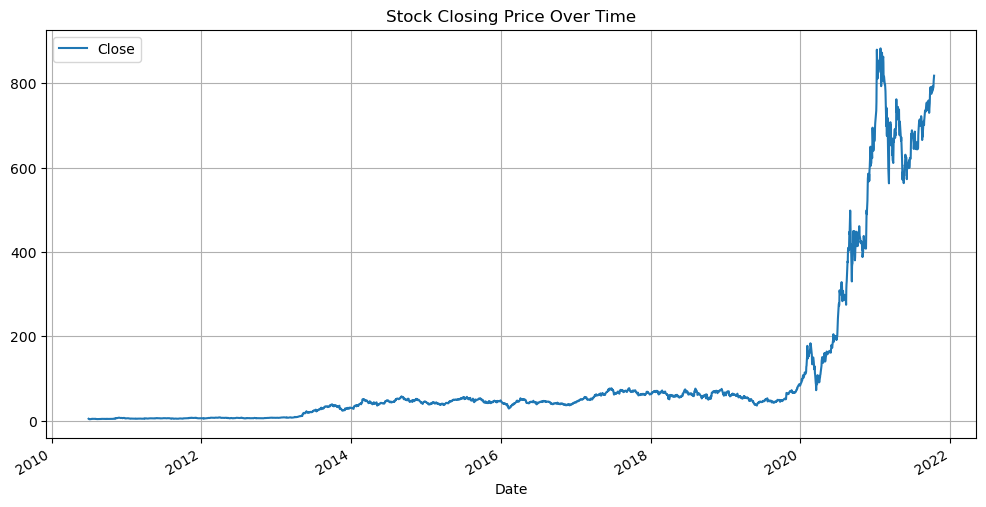

In [14]:
data.plot.line(y="Close", use_index=True, title="Stock Closing Price Over Time", figsize=(12,6), grid=True)


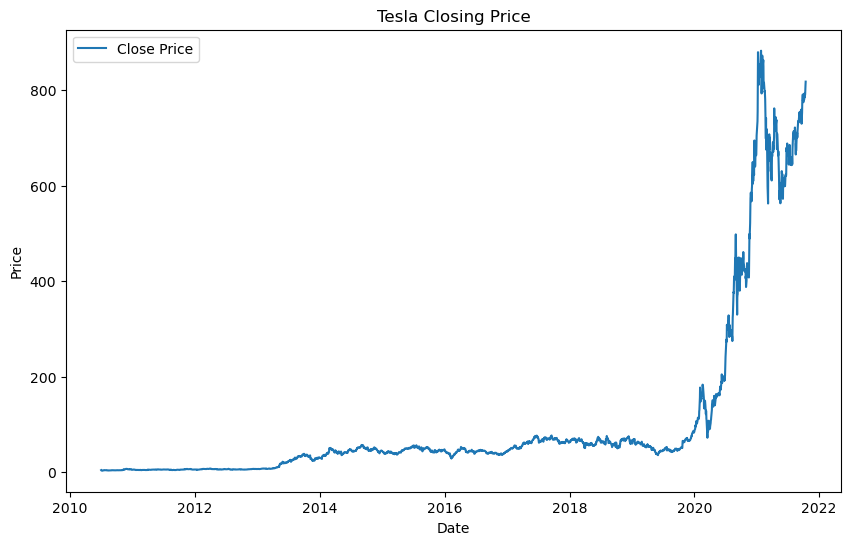

In [15]:
import matplotlib.pyplot as plt

# Example plot
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], label='Close Price')
plt.title("Tesla Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

# Save the plot as a PNG image
plt.savefig("tesla_close_price.png", dpi=300, bbox_inches='tight')

plt.show()


## Create Moving Average columns:

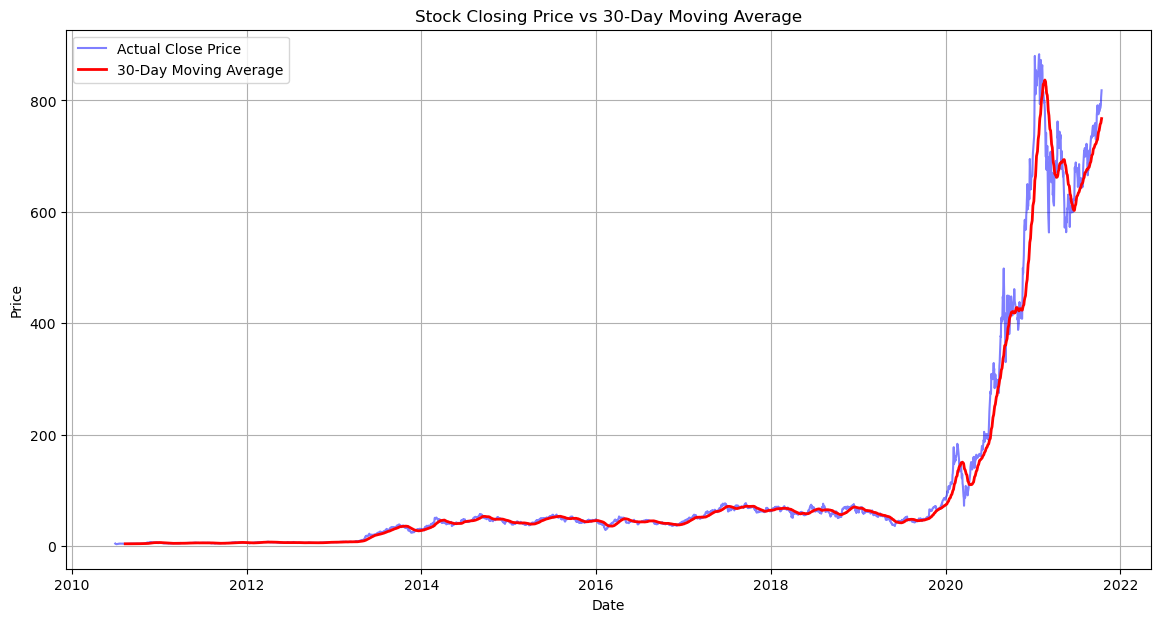

In [16]:
import matplotlib.pyplot as plt

data['Open_MA30'] = data['Open'].rolling(window=30).mean() #Takes the average of the last 30 days for every point
data['High_MA30'] = data['High'].rolling(window=30).mean()
data['Low_MA30'] = data['Low'].rolling(window=30).mean()
data['Close_MA30'] = data['Close'].rolling(window=30).mean()
data['Volume_MA30'] = data['Volume'].rolling(window=30).mean()

# Plot both Close price and 30-day moving average
plt.figure(figsize=(14,7))
plt.plot(data.index, data['Close'], label='Actual Close Price', color='blue', alpha=0.5)
plt.plot(data.index, data['Close_MA30'], label='30-Day Moving Average', color='red', linewidth=2)

plt.title('Stock Closing Price vs 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [17]:
data.head()

,Open,High,Low,Close,Volume,Open_MA30,High_MA30,Low_MA30,Close_MA30,Volume_MA30
Date,,,,,,,,,,
2010-07-01,5.000,5.184,4.054,4.392,41094000,NaN,NaN,NaN,NaN,NaN
2010-07-02,4.600,4.620,3.742,3.840,25699000,NaN,NaN,NaN,NaN,NaN
2010-07-06,4.000,4.000,3.166,3.222,34334500,NaN,NaN,NaN,NaN,NaN
2010-07-07,3.280,3.326,2.996,3.160,34608500,NaN,NaN,NaN,NaN,NaN
2010-07-08,3.228,3.504,3.114,3.492,38557000,NaN,NaN,NaN,NaN,NaN


In [18]:
data.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Open_MA30      29
High_MA30      29
Low_MA30       29
Close_MA30     29
Volume_MA30    29
dtype: int64

In [19]:
data = data.dropna(subset=['Open_MA30','High_MA30','Low_MA30','Close_MA30','Volume_MA30' ])


In [20]:
data.head(10)


,Open,High,Low,Close,Volume,Open_MA30,High_MA30,Low_MA30,Close_MA30,Volume_MA30
Date,,,,,,,,,,
2010-08-12,3.560,3.580,3.478,3.520,3455000,4.017800,4.111067,3.801467,3.926800,1.209302e+07
2010-08-13,3.636,3.690,3.532,3.664,3170000,3.972333,4.061267,3.784067,3.902533,1.082888e+07
2010-08-16,3.690,3.760,3.652,3.756,2429000,3.942000,4.032600,3.781067,3.899733,1.005322e+07
2010-08-17,3.792,3.880,3.756,3.830,2239500,3.935067,4.028600,3.800733,3.920000,8.983383e+06
2010-08-18,3.918,3.918,3.720,3.754,3006500,3.956333,4.048333,3.824867,3.939800,7.929983e+06
2010-08-19,3.708,3.850,3.666,3.758,2895500,3.972333,4.059867,3.843267,3.948667,6.741267e+06
2010-08-20,3.730,3.822,3.702,3.820,1480000,3.979467,4.067933,3.856333,3.960000,6.115500e+06
2010-08-23,3.818,4.078,3.800,4.026,5440500,3.987067,4.083400,3.869667,3.980533,5.929767e+06
2010-08-24,3.850,3.942,3.790,3.840,3365500,3.999467,4.090533,3.883333,3.987600,5.595267e+06


In [21]:
data.shape

(2814, 10)

C:\Users\hp\AppData\Local\Temp\ipykernel_5328\3816085875.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(data[col])
C:\Users\hp\AppData\Local\Temp\ipykernel_5328\3816085875.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(data[col])
C:\Users\hp\AppData\Local\Temp\ipykernel_5328\3816085875.p

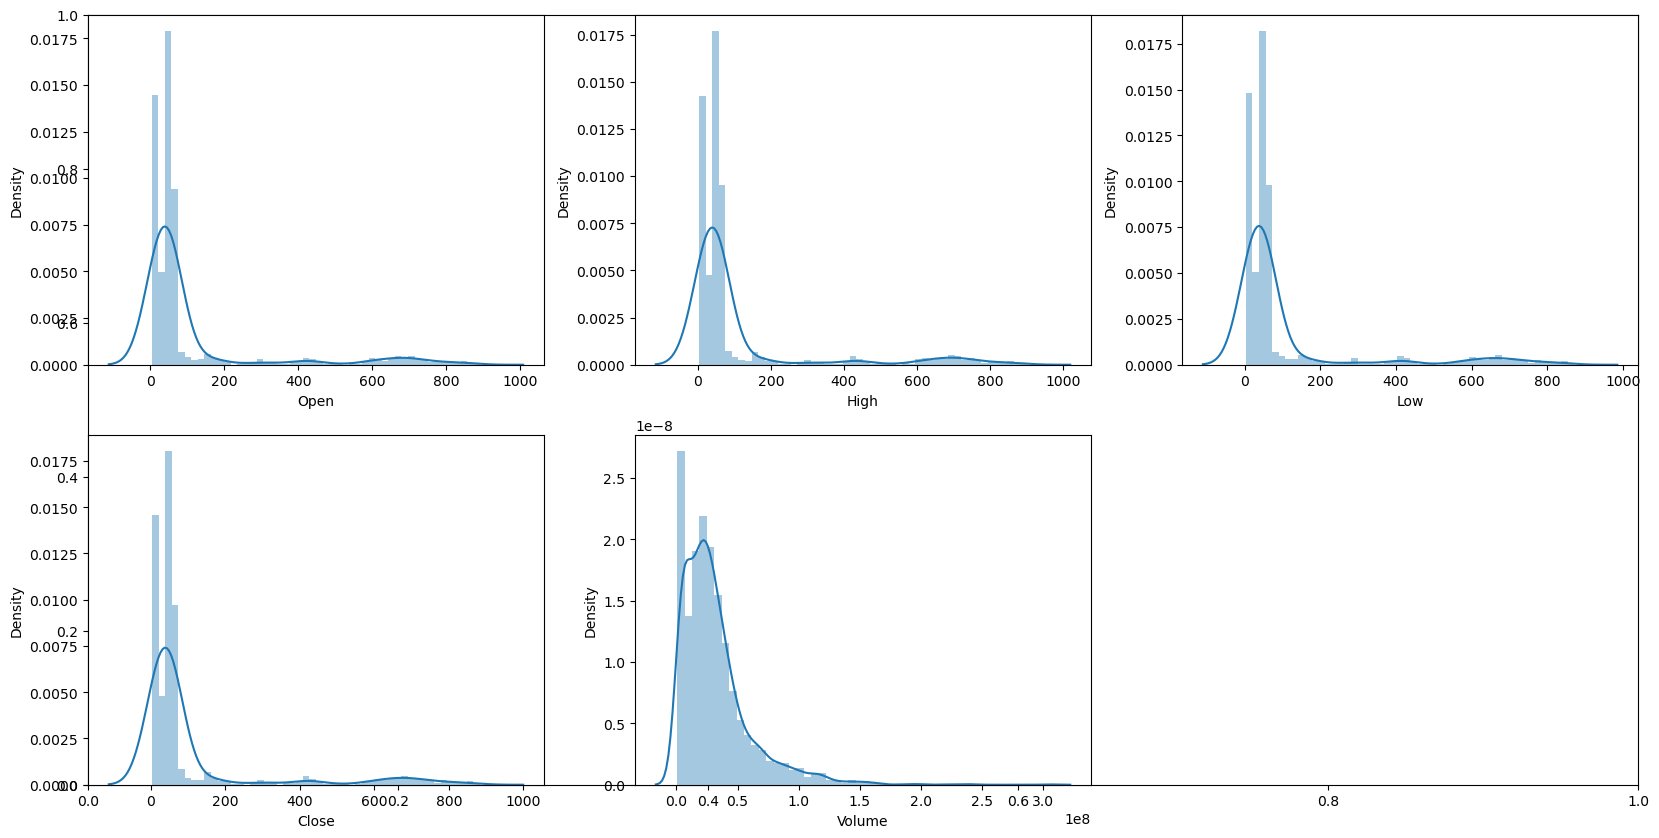

In [22]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.distplot(data[col])
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_5328\1216508974.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(data[col])
C:\Users\hp\AppData\Local\Temp\ipykernel_5328\1216508974.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(data[col])
C:\Users\hp\AppData\Local\Temp\ipykernel_5328\1216508974.p

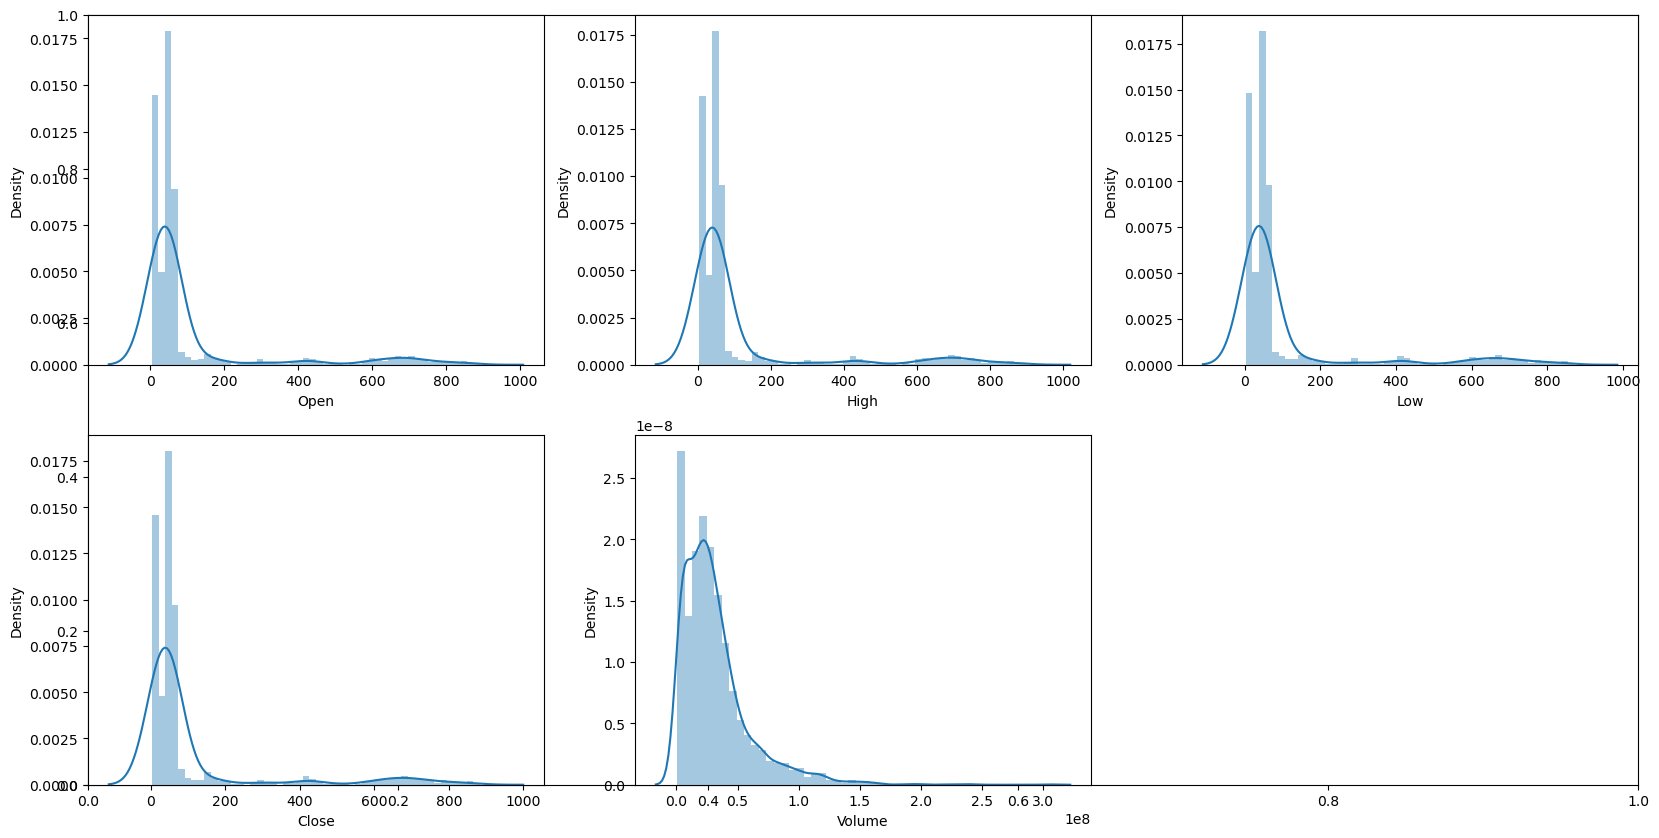

In [23]:
features_1 = ['Open_MA30','High_MA30','Low_MA30','Close_MA30','Volume_MA30']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.distplot(data[col])
plt.show()

# What can we learn from these histograms?
### Feature(Open, High, Low, Close) -> What the histogram tells : How stock prices are distributed: Are they concentrated around certain values? Are they skewed (mostly small values or mostly big values)?.
### Feature(Volume ) -> What the histogram tells : How much trading activity there is: Are most days low volume? Are there some spikes with very high                           trading volume?

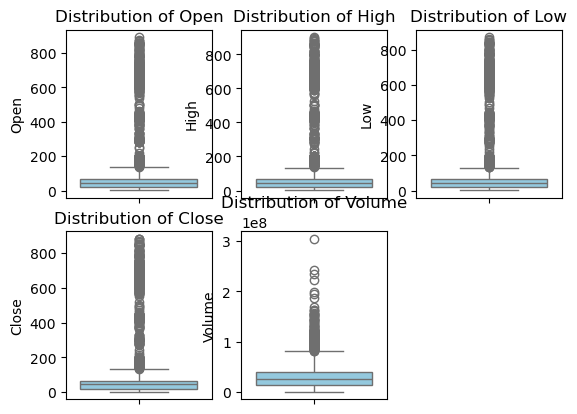

In [24]:
for i, col in enumerate(features):
    plt.subplot(2,3,i+1)
    sb.boxplot(y=data[col], color='skyblue')
    plt.title(f'Distribution of {col}')


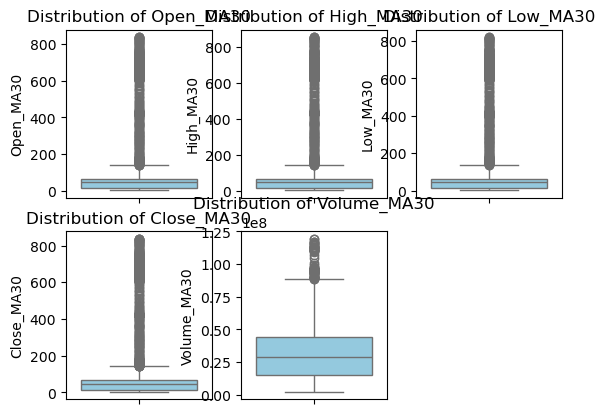

In [25]:
for i, col in enumerate(features_1):
    plt.subplot(2,3,i+1)
    sb.boxplot(y=data[col], color='skyblue')
    plt.title(f'Distribution of {col}')


In [26]:
#sb.boxplot(data_clean_close["Close"])

## Detect Outliers Of Actual Feature

In [27]:
def detect_outliers_all_features(data, features):
    outliers_dict = {}

    for col in features:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outliers_dict[col] = outliers

        print(f"{col}: {len(outliers)} outliers detected.")
    
    return outliers_dict

# Apply to your features
outliers_all = detect_outliers_all_features(data, features)
outliers_all 

Open: 403 outliers detected.
High: 405 outliers detected.
Low: 404 outliers detected.
Close: 404 outliers detected.
Volume: 178 outliers detected.


{'Open':                   Open        High         Low       Close     Volume  \
 Date                                                                    
 2020-02-04  176.591995  193.798004  166.776001  177.412003  304694000   
 2020-02-05  164.651993  169.195999  140.822006  146.940002  242119000   
 2020-02-06  139.983994  159.166000  137.399994  149.792007  199404000   
 2020-02-07  146.110001  153.949997  146.000000  149.613998   85317500   
 2020-02-10  160.000000  163.998001  150.479996  154.255997  123446000   
 ...                ...         ...         ...         ...        ...   
 2021-10-08  796.210022  796.380005  780.909973  785.489990   16711100   
 2021-10-11  787.650024  801.239990  785.500000  791.940002   14200300   
 2021-10-12  800.929993  812.320007  796.570007  805.719971   22020000   
 2021-10-13  810.469971  815.409973  805.780029  811.080017   14120100   
 2021-10-14  815.489990  820.250000  813.349976  818.320007   12203200   
 
              Open_MA30   Hi

## Detect Outliers Of  Moving Feature

In [28]:
def detect_outliers_all_features(data, features_1):
    outliers_dict = {}

    for col in features_1:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outliers_dict[col] = outliers

        print(f"{col}: {len(outliers)} outliers detected.")
    
    return outliers_dict

# Apply to your features
outliers_all = detect_outliers_all_features(data, features_1)
outliers_all 

Open_MA30: 375 outliers detected.
High_MA30: 379 outliers detected.
Low_MA30: 370 outliers detected.
Close_MA30: 375 outliers detected.
Volume_MA30: 77 outliers detected.


{'Open_MA30':                   Open        High         Low       Close     Volume  \
 Date                                                                    
 2020-02-27  146.000000  147.953995  133.800003  135.800003  121386000   
 2020-02-28  125.940002  138.104004  122.304001  133.598007  121114500   
 2020-03-02  142.251999  148.738007  137.334000  148.723999  100975000   
 2020-03-03  161.000000  161.395996  143.222000  149.102005  128920000   
 2020-03-04  152.792007  153.304001  144.945999  149.899994   75245000   
 ...                ...         ...         ...         ...        ...   
 2021-10-08  796.210022  796.380005  780.909973  785.489990   16711100   
 2021-10-11  787.650024  801.239990  785.500000  791.940002   14200300   
 2021-10-12  800.929993  812.320007  796.570007  805.719971   22020000   
 2021-10-13  810.469971  815.409973  805.780029  811.080017   14120100   
 2021-10-14  815.489990  820.250000  813.349976  818.320007   12203200   
 
              Open_MA30

## Remove Outliers Of Actual Feature

In [29]:
def remove_outliers_all_features(data, features):
    for col in features:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    
    return data

# Cleaned dataset
data = remove_outliers_all_features(data, features)


In [30]:
remove_outliers_all_features(data, features)

,Open,High,Low,Close,Volume,Open_MA30,High_MA30,Low_MA30,Close_MA30,Volume_MA30
Date,,,,,,,,,,
2010-08-12,3.560000,3.580000,3.478000,3.520000,3455000,4.017800,4.111067,3.801467,3.926800,1.209302e+07
2010-08-13,3.636000,3.690000,3.532000,3.664000,3170000,3.972333,4.061267,3.784067,3.902533,1.082888e+07
2010-08-16,3.690000,3.760000,3.652000,3.756000,2429000,3.942000,4.032600,3.781067,3.899733,1.005322e+07
2010-08-17,3.792000,3.880000,3.756000,3.830000,2239500,3.935067,4.028600,3.800733,3.920000,8.983383e+06
2010-08-18,3.918000,3.918000,3.720000,3.754000,3006500,3.956333,4.048333,3.824867,3.939800,7.929983e+06
...,...,...,...,...,...,...,...,...,...,...
2020-03-27,101.000000,105.160004,98.806000,102.872002,71887000,130.642000,135.081134,124.693466,129.398999,9.594697e+07
2020-03-30,102.052002,103.330002,98.246002,100.426003,59990500,128.795601,133.105667,122.731666,127.413000,9.533103e+07
2020-04-01,100.800003,102.790001,95.019997,96.311996,66766000,123.729934,128.119868,117.656466,122.277933,9.355103e+07


## Remove Outliers Of Moving Feature

In [31]:
def remove_outliers_all_features(data, features_1):
    for col in features_1:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    
    return data

# Cleaned dataset
data = remove_outliers_all_features(data, features_1)


In [32]:
remove_outliers_all_features(data, features_1)

,Open,High,Low,Close,Volume,Open_MA30,High_MA30,Low_MA30,Close_MA30,Volume_MA30
Date,,,,,,,,,,
2010-08-12,3.560000,3.580000,3.478000,3.520000,3455000,4.017800,4.111067,3.801467,3.926800,1.209302e+07
2010-08-13,3.636000,3.690000,3.532000,3.664000,3170000,3.972333,4.061267,3.784067,3.902533,1.082888e+07
2010-08-16,3.690000,3.760000,3.652000,3.756000,2429000,3.942000,4.032600,3.781067,3.899733,1.005322e+07
2010-08-17,3.792000,3.880000,3.756000,3.830000,2239500,3.935067,4.028600,3.800733,3.920000,8.983383e+06
2010-08-18,3.918000,3.918000,3.720000,3.754000,3006500,3.956333,4.048333,3.824867,3.939800,7.929983e+06
...,...,...,...,...,...,...,...,...,...,...
2020-01-10,96.358002,96.987999,94.739998,95.629997,64797500,78.335400,79.812000,77.427467,78.922133,5.716185e+07
2020-01-17,101.522003,103.134003,100.632004,102.099998,68145500,84.381267,86.236467,83.288934,85.188399,7.083618e+07
2020-01-24,114.125999,114.772003,110.851997,112.963997,71768000,90.332200,92.439667,89.028667,91.182733,7.983430e+07


<Axes: ylabel='Close'>

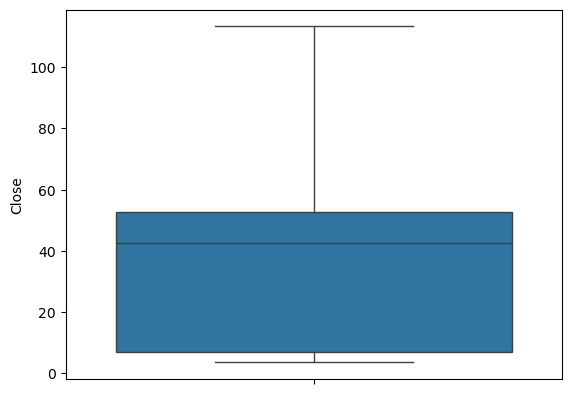

In [33]:
#sb.boxplot(data["Close"])
sb.boxplot(data["Close"])

## Actual Feature

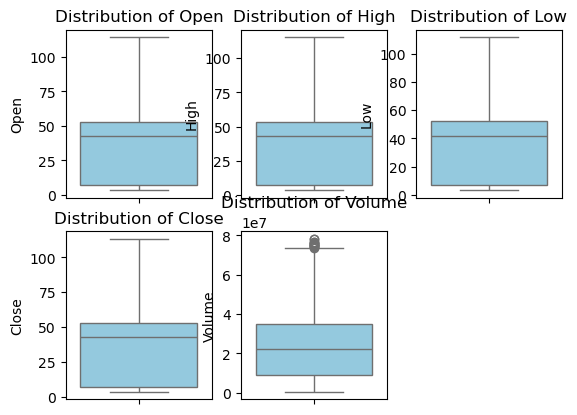

In [34]:
for i, col in enumerate(features):
    plt.subplot(2,3,i+1)
    sb.boxplot(y=data[col], color='skyblue')
    plt.title(f'Distribution of {col}')

## Moving Feature

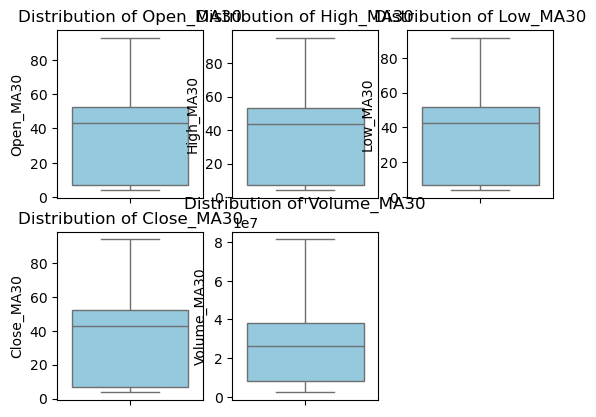

In [35]:
for i, col in enumerate(features_1):
    plt.subplot(2,3,i+1)
    sb.boxplot(y=data[col], color='skyblue')
    plt.title(f'Distribution of {col}')

In [36]:
data

,Open,High,Low,Close,Volume,Open_MA30,High_MA30,Low_MA30,Close_MA30,Volume_MA30
Date,,,,,,,,,,
2010-08-12,3.560000,3.580000,3.478000,3.520000,3455000,4.017800,4.111067,3.801467,3.926800,1.209302e+07
2010-08-13,3.636000,3.690000,3.532000,3.664000,3170000,3.972333,4.061267,3.784067,3.902533,1.082888e+07
2010-08-16,3.690000,3.760000,3.652000,3.756000,2429000,3.942000,4.032600,3.781067,3.899733,1.005322e+07
2010-08-17,3.792000,3.880000,3.756000,3.830000,2239500,3.935067,4.028600,3.800733,3.920000,8.983383e+06
2010-08-18,3.918000,3.918000,3.720000,3.754000,3006500,3.956333,4.048333,3.824867,3.939800,7.929983e+06
...,...,...,...,...,...,...,...,...,...,...
2020-01-10,96.358002,96.987999,94.739998,95.629997,64797500,78.335400,79.812000,77.427467,78.922133,5.716185e+07
2020-01-17,101.522003,103.134003,100.632004,102.099998,68145500,84.381267,86.236467,83.288934,85.188399,7.083618e+07
2020-01-24,114.125999,114.772003,110.851997,112.963997,71768000,90.332200,92.439667,89.028667,91.182733,7.983430e+07


## Why Detect Outliers?
#### Improve model performance -> Many machine learning models (like Linear Regression) get skewed by extreme values. Outliers can distort                                                the learned patterns.
#### Better statistics -> 	Outliers can inflate or deflate averages, standard deviation, and variance, making your data summary misleading.
#### Cleaner visualizations -> 	Outliers can stretch graphs (like histograms and boxplots), making it harder to see the overall pattern.
#### Anomaly detection	-> In fraud or error detection, outliers are actually the point — they may indicate mistakes, fraud, or rare events worth attention.

## Why Remove Outliers?
#### -To make your dataset more robust, accurate, and stable.
#### -To avoid noise in training a model.
#### -To improve generalization of ML models — meaning they perform better on new, unseen data



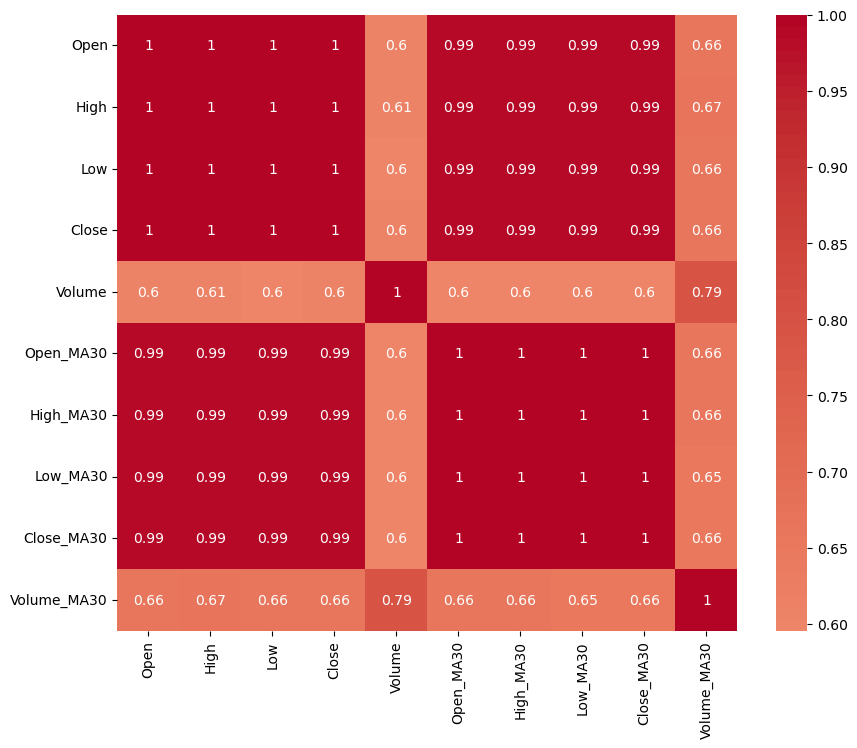

In [37]:
plt.figure(figsize=(10,8))
sb.heatmap(data.corr(), annot=True, cmap='coolwarm', center=0)
plt.show()


## interpretation  
### 1.	data.corr()
#### This calculates the correlation matrix between all numeric columns of your data DataFrame.
#### Correlation means how strongly two variables move together.
#### Value close to +1 → strong positive correlation (they move together).
#### Value close to -1 → strong negative correlation (they move oppositely).
#### Value around 0 → no correlation (no clear relationship).



# 4 Feature Engineering 

In [38]:
#create Target Variable 
data['Next_Days']=data['Close'].shift(-1)

In [39]:
data.head()

,Open,High,Low,Close,Volume,Open_MA30,High_MA30,Low_MA30,Close_MA30,Volume_MA30,Next_Days
Date,,,,,,,,,,,
2010-08-12,3.560,3.580,3.478,3.520,3455000,4.017800,4.111067,3.801467,3.926800,1.209302e+07,3.664
2010-08-13,3.636,3.690,3.532,3.664,3170000,3.972333,4.061267,3.784067,3.902533,1.082888e+07,3.756
2010-08-16,3.690,3.760,3.652,3.756,2429000,3.942000,4.032600,3.781067,3.899733,1.005322e+07,3.830
2010-08-17,3.792,3.880,3.756,3.830,2239500,3.935067,4.028600,3.800733,3.920000,8.983383e+06,3.754
2010-08-18,3.918,3.918,3.720,3.754,3006500,3.956333,4.048333,3.824867,3.939800,7.929983e+06,3.758


In [40]:
data.isnull().sum()

Open           0
High           0
Low            0
Close          0
Volume         0
Open_MA30      0
High_MA30      0
Low_MA30       0
Close_MA30     0
Volume_MA30    0
Next_Days      1
dtype: int64

In [41]:
data=data[:-1] # drop the last row NAN

In [42]:
data.head(2843)

,Open,High,Low,Close,Volume,Open_MA30,High_MA30,Low_MA30,Close_MA30,Volume_MA30,Next_Days
Date,,,,,,,,,,,
2010-08-12,3.560000,3.580000,3.478000,3.520000,3455000,4.017800,4.111067,3.801467,3.926800,1.209302e+07,3.664000
2010-08-13,3.636000,3.690000,3.532000,3.664000,3170000,3.972333,4.061267,3.784067,3.902533,1.082888e+07,3.756000
2010-08-16,3.690000,3.760000,3.652000,3.756000,2429000,3.942000,4.032600,3.781067,3.899733,1.005322e+07,3.830000
2010-08-17,3.792000,3.880000,3.756000,3.830000,2239500,3.935067,4.028600,3.800733,3.920000,8.983383e+06,3.754000
2010-08-18,3.918000,3.918000,3.720000,3.754000,3006500,3.956333,4.048333,3.824867,3.939800,7.929983e+06,3.758000
...,...,...,...,...,...,...,...,...,...,...,...
2020-01-06,88.094002,90.311996,88.000000,90.307999,50665000,74.737200,75.999000,73.943467,75.138400,4.930205e+07,95.629997
2020-01-10,96.358002,96.987999,94.739998,95.629997,64797500,78.335400,79.812000,77.427467,78.922133,5.716185e+07,102.099998
2020-01-17,101.522003,103.134003,100.632004,102.099998,68145500,84.381267,86.236467,83.288934,85.188399,7.083618e+07,112.963997


# 5 Data Splitting 

## Moving Feature

In [43]:

# Define features
#features=['Open', 'High', 'Low', 'Close', 'Volume',]
features_1=['Open_MA30','High_MA30','Low_MA30','Close_MA30','Volume_MA30']
x=data[features_1]
y=data['Next_Days']
# Split data into training and testing sets
x_train_1,x_test_1,y_train_1,y_test_1=train_test_split(x,y,test_size=0.25,random_state=30)

## Actual Feature

In [44]:
# Define features
features=['Open', 'High', 'Low', 'Close', 'Volume',]
#features=['Open_MA30','High_MA30','Low_MA30','Close_MA30','Volume_MA30']
x=data[features]
y=data['Next_Days']
# Split data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=30)

In [45]:
print(x.shape,x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(2278, 5) (1708, 5) (570, 5) (1708,) (570,)


# 6 Model Building And  Training 

## Moving Feature

In [46]:
from sklearn.ensemble import RandomForestRegressor

model_1 = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,          # Limit depth of trees
    min_samples_split=10,  # Minimum samples to split
    min_samples_leaf=5,    # Minimum samples in leaf
    random_state=42
)

model_1.fit(x_train_1, y_train_1)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

## Actual Feature

In [47]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,          # Limit depth of trees
    min_samples_split=10,  # Minimum samples to split
    min_samples_leaf=5,    # Minimum samples in leaf
    random_state=42
)

model.fit(x_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

# 7 Make prediction

## Moving Feature

In [48]:
y_predict_1 =model_1.predict(x_test_1)

In [49]:
y_predict_1

array([46.8640871 , 48.88815155, 59.81116979, 52.88503279, 39.30542574,
       70.75430061, 46.09177065,  6.03846318, 65.68546787,  5.74321983,
        4.76715901, 39.13157591, 70.24120222, 42.34342908,  6.87358638,
        6.98693791,  5.12875406, 67.51571324,  5.43505921, 36.64747424,
       38.64781192, 58.73600677, 47.60382674, 59.22527395, 33.65898467,
       69.58056141, 48.84908927,  5.34619396, 64.72042341,  5.84644894,
        5.47296858, 46.07815842, 58.59158398, 40.18551588, 48.56568201,
        5.32749522, 47.27369805,  5.59322944, 64.92906858, 63.81442597,
       62.97401621, 41.60075994,  7.7045978 , 39.82063922, 39.75517991,
        7.12553231, 36.64713825, 64.17951118, 51.29011014, 10.31894098,
       44.51829405, 46.2431788 , 64.05962686, 66.51374997,  5.46252461,
       46.5007206 , 64.56113493, 42.08032832, 77.89430126, 43.38598786,
       64.22857965, 40.17171287,  8.1549446 , 39.43549518, 52.50048388,
       34.39434807, 39.93227725,  5.25012721,  5.1901662 , 42.59

## Actual Feature

In [50]:
y_predict =model.predict(x_test)

In [51]:
y_predict

array([44.83118577, 49.92688946, 56.9244793 , 63.15412034, 37.81283658,
       67.81272908, 52.31898624,  5.81991157, 66.1825022 ,  5.69062172,
        4.67809637, 37.52194554, 63.94809704, 39.13054361,  7.01447583,
        6.81297493,  4.70043168, 66.96366177,  5.65718426, 33.1294515 ,
       38.38833312, 57.7683875 , 50.12523134, 63.51701108, 32.37452227,
       64.11020336, 51.57469099,  5.16028814, 63.53416583,  6.03631777,
        4.78455858, 40.53388951, 54.33555333, 40.54969613, 52.55873053,
        5.55290947, 44.10391005,  5.58556571, 66.54612092, 67.77000721,
       71.69647985, 40.64102154,  8.72467853, 38.99342759, 37.21092223,
        6.6465109 , 46.51544922, 67.55567643, 62.55969444, 10.71888274,
       46.47409136, 46.71218646, 67.43934594, 69.84433956,  4.77828943,
       51.02874022, 61.54969732, 45.79245541, 73.19173096, 41.10610799,
       71.29275918, 41.75892068,  8.37926087, 45.19941041, 48.35004685,
       32.97553839, 40.14887487,  5.15358687,  4.60764183, 44.67

In [52]:
y_train_11 = model_1.predict(x_train_1)

In [53]:
y_train_11

array([ 6.01950492, 38.754291  ,  5.59157663, ...,  5.90783234,
        6.66710437, 68.08545752])

In [54]:
y_train_22=model.predict(x_train)

In [55]:
y_train_22

array([ 5.92596642, 38.96991262,  5.62548565, ...,  5.71680013,
        6.65130005, 67.7568143 ])

# 8 Evaluate the Model

## Moving Feature

In [56]:
# Evaluate the model on test data 
MSE=mean_squared_error(y_test_1,y_predict_1)
R2=r2_score(y_test_1,y_predict_1)
print(f"Mean Square Error is:{MSE}")
print(f"R-Squared is :{R2}")

Mean Square Error is:11.853689175588658
R-Squared is :0.9782347603335486


In [57]:
# Evaluate the model on tarining data
MSE=mean_squared_error(y_train_11,y_train_1)
R2=r2_score(y_train_11,y_train_1)
print(f"Mean Square Error is:{MSE}")
print(f"R-Squared is :{R2}")

Mean Square Error is:5.137655432765331
R-Squared is :0.9901110105458195


## Actual Feature

In [58]:
# Evaluate the model on test data 
MSE=mean_squared_error(y_test,y_predict)
R2=r2_score(y_test,y_predict)
print(f"Mean Square Error is:{MSE}")
print(f"R-Squared is :{R2}")

Mean Square Error is:2.7731358842896707
R-Squared is :0.9949080858916478


In [59]:
# Evaluate the model on tarining data
MSE=mean_squared_error(y_train_22,y_train)
R2=r2_score(y_train,y_train_22)
print(f"Mean Square Error is:{MSE}")
print(f"R-Squared is :{R2}")

Mean Square Error is:1.62245103333997
R-Squared is :0.9969361188580933


## •	Calculates the Mean Squared Error (MSE) and R-Squared
### •	MSE = the average of the squared differences between the actual (y_test) and predicted (y_predict) values.
####           o	Lower MSE → Better model.
####           o	Higher MSE → Worse model (predictions far from actual).
### • R² measures how much of the variability in the target is explained by the model or to measure the goodness of the model
   #### o	R² = 1 → Perfect prediction (model explains 100% of variance).
   #### o	R² = 0 → Model is no better than just predicting the mean.
   #### o	R² < 0 → Model is worse than predicting the mean (bad model).

 ### from our result  the MSE is very small and R-Squared is approach to 1 so that our model good fit 
 #### Compare Test data with Training Data
 ### from our result both Training Data and Test data of MSE is small and R-Squared is approach to 1,the model is good fit
 

In [60]:
import numpy as np
   
# Generate X_grid with 3 features
###X_grid = np.hstack((X_grid, np.zeros((X_grid.shape[0], 2))))  # Pad with zeros

# Plot results
#plt.scatter(x[:, 0], y, color='blue', label="Actual Data")  # Plot first feature vs target
#plt.plot(X_grid[:, 0], regressor.predict(X_grid), color='green', label="Random Forest Prediction")  
#plt.title("Random Forest Regression Results")
#plt.xlabel('Position Level')
##plt.legend()
#plt.show()

## Moving feature

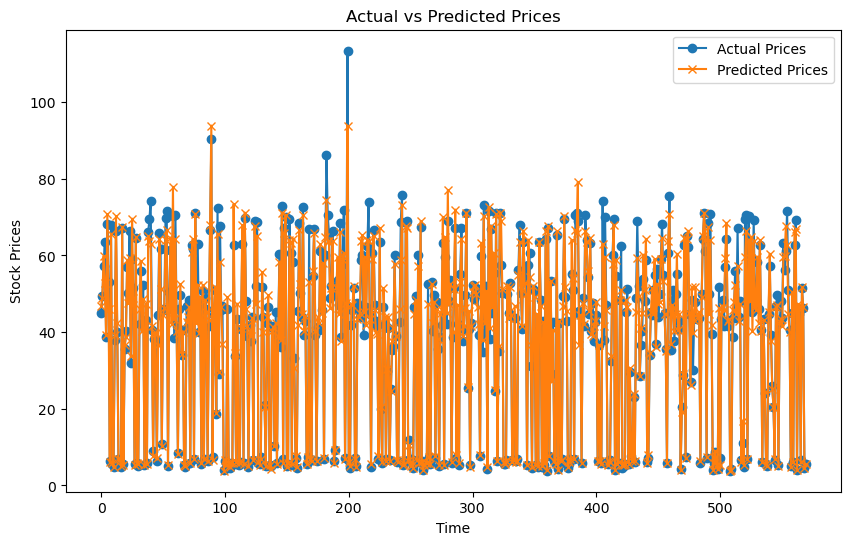

In [61]:
plt.figure(figsize=(10,6)) # Creates a plot window that is 10 units wide and 6 units tall.
plt.plot(y_test_1.values,label="Actual Prices", marker='o')# Plots the true stock prices from y_test.
plt.plot(y_predict_1, label="Predicted Prices", marker='x')# Plots the predicted stock prices from y_predict
plt.legend() # 	Adds a legend to explain which line is actual and which is predicted.
plt.xlabel("Time")
plt.ylabel("Stock Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

## Actual feature

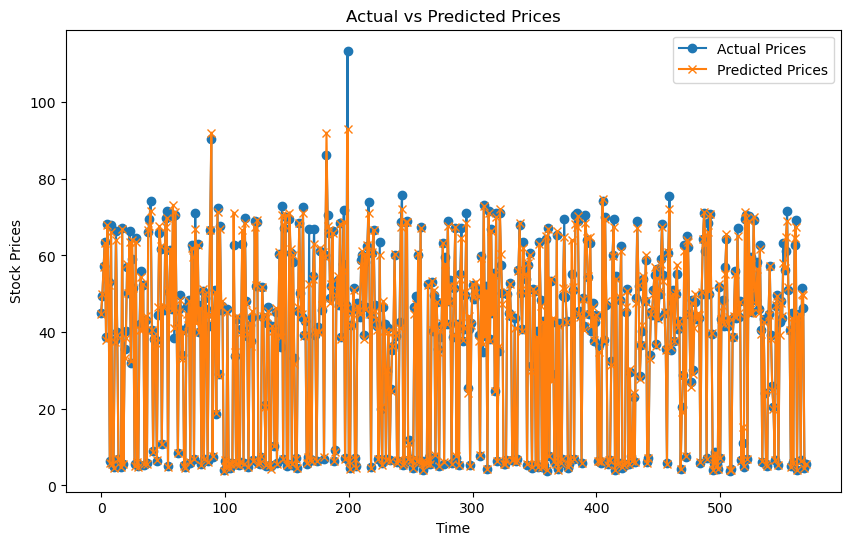

In [62]:
plt.figure(figsize=(10,6)) # Creates a plot window that is 10 units wide and 6 units tall.
plt.plot(y_test.values,label="Actual Prices", marker='o')# Plots the true stock prices from y_test.
plt.plot(y_predict, label="Predicted Prices", marker='x')# Plots the predicted stock prices from y_predict
plt.legend() # 	Adds a legend to explain which line is actual and which is predicted.
plt.xlabel("Time")
plt.ylabel("Stock Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

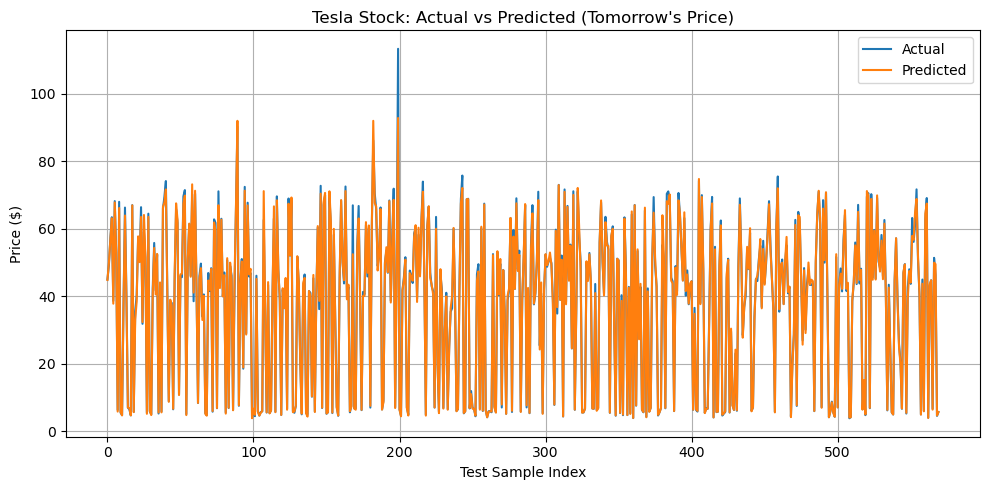

In [63]:
# 11. Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_predict, label='Predicted')
plt.title("Tesla Stock: Actual vs Predicted (Tomorrow's Price)")
plt.xlabel("Test Sample Index")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Interpretation of  the Plot graph:
### •	You will see two lines:
#### One for Actual Prices (real stock prices).
#### One for Predicted Prices (model's output).
### •	Good Model:
#### The two lines will closely follow each other.
#### Small gaps between Actual and Predicted.
### •	Bad Model:
#### The two lines will be far apart.
#### Predicted prices will miss important jumps or drops.

### On other hund
#### Predicted line ≈ Actual line: then the model is Good model 
#### Predicted line ≠ Actual line (big gaps): then the model Bad model 

### from the above visualization plot our model is almost good because the plot will show two almost overlapping lines → Good prediction!

# 9 Model Deployment 

In [64]:
# Example unseen data (1 sample with same columns as X_test)
unseen_sample = [[3.560000,3.580000,3.478000,3.520000,3455000]]  # 5 features for price prediction


In [65]:
y_predict1 =model_1.predict(unseen_sample )

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [66]:
y_predict1

array([4.09283713])

In [67]:
y_predict2 =model.predict(unseen_sample )

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [68]:
y_predict2

array([3.84635739])

## Tkinter GUI For Deployment 

In [69]:
import joblib

# Assuming your trained model is named 'model'
joblib.dump(model, 'tesla_model.pkl')

['tesla_model.pkl']

In [76]:
import gradio as gr
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tempfile
from sklearn.metrics import mean_absolute_error

# Load trained model
model = joblib.load("tesla_model.pkl")

def compare_actual_predicted(data):
    try:
        df = pd.DataFrame(data)

        if 'Date' not in df.columns:
            return "Error: 'Date' column is required", None, None

        df = df.dropna()
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df = df.dropna(subset=['Date'])

        feature_cols = model.feature_names_in_ if hasattr(model, "feature_names_in_") else ['Open', 'High', 'Low', 'Volume', 'Close']
        for col in feature_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df = df.dropna(subset=feature_cols)

        # Predict
        df['Predicted_Close'] = model.predict(df[feature_cols])

        # Calculate error if actual Close is present
        mae = None
        if 'Close' in df.columns:
            mae = mean_absolute_error(df['Close'], df['Predicted_Close'])

        # Prepare text output
        prediction_lines = [
            f"{date.date()} → Actual: ${actual:.2f} | Predicted: ${pred:.2f}"
            for date, actual, pred in zip(df['Date'], df['Close'], df['Predicted_Close'])
        ]
        text_output = "\n".join(prediction_lines)
        if mae is not None:
            text_output += f"\n\n📉 MAE: {mae:.2f}"

        # Plot actual vs predicted
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(df['Date'], df['Close'], marker='o', label="Actual", color='green')
        ax.plot(df['Date'], df['Predicted_Close'], marker='x', label="Predicted", color='blue')
        ax.set_title("Actual vs Predicted Close Prices")
        ax.set_xlabel("Date")
        ax.set_ylabel("Close Price ($)")
        ax.legend()
        ax.grid(True)
        fig.autofmt_xdate()

        # Save to temp CSV
        temp_file = tempfile.NamedTemporaryFile(delete=False, suffix=".csv")
        df.to_csv(temp_file.name, index=False)

        return text_output, fig, temp_file.name

    except Exception as e:
        return f"Error: {str(e)}", None, None

# Gradio app
gr.Interface(
    fn=compare_actual_predicted,
    inputs=gr.Dataframe(headers=["Date", "Open", "High", "Low", "Volume", "Close"], row_count=5),
    outputs=[
        gr.Text(label="Predicted vs Actual"),
        gr.Plot(label="Graph"),
        gr.File(label="Download .CSV")
    ],
    title="📊 Tesla Stock: Actual vs Predicted",
    description="Compare actual and predicted close prices. Includes graph, MAE, and downloadable CSV."
).launch()


* Running on local URL:  http://127.0.0.1:7873
* To create a public link, set `share=True` in `launch()`.
